# Notebook 03 — UK Inflation Expectations and Real Yield Decomposition

## Purpose
Analyse how UK inflation expectations evolved through the 2021–2024 inflation cycle.
Test whether markets systematically underpriced the inflation surge.
Decompose nominal gilt yields into real yield and inflation expectations components.

## Research Question
Did markets believe the transitory inflation narrative in 2021? When did they stop? 
Was the gilt yield sell-off driven by rising real yields or rising inflation expectations?

## Key Analysis
- Breakeven inflation: nominal gilt yield minus index-linked gilt yield (5yr and 10yr)
- Breakeven inflation vs realised CPI — measuring the underpricing gap
- Structural break identification — when did the transitory narrative collapse?
- Real yield decomposition: nominal yield = real yield + breakeven inflation
- Comparison with US TIPS decomposition (FRED data)
- Investment signal: when to prefer index-linked gilts over nominal gilts

## Reads from
`/data/processed/uk_gilts_nominal.csv`  
`/data/processed/uk_gilts_indexlinked.csv`  
`/data/processed/us_tips.csv`

In [1]:
# ============================================================
# SETUP — WORKING DIRECTORY, IMPORTS, LOAD DATA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# Fix working directory — must run at start of every notebook
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

print(f"Working directory: {os.getcwd()}")

# Load UK nominal gilt spot curve
gilts_nominal = pd.read_csv('data/processed/uk_gilts_nominal.csv',
                             index_col=0, parse_dates=True)
gilts_nominal.index.name = 'date'

# Load UK real gilt spot curve
gilts_real = pd.read_csv('data/processed/uk_gilts_real.csv',
                          index_col=0, parse_dates=True)
gilts_real.index.name = 'date'

# Load BoE inflation curve
inflation_curve = pd.read_csv('data/processed/uk_inflation_curve.csv',
                               index_col=0, parse_dates=True)
inflation_curve.index.name = 'date'

# Confirm all loaded correctly
for name, df in [('Nominal gilts', gilts_nominal),
                 ('Real gilts',    gilts_real),
                 ('Inflation curve', inflation_curve)]:
    print(f"{name}: {df.shape[0]} rows, "
          f"{df.index[0].date()} to {df.index[-1].date()}, "
          f"nulls: {df.isnull().sum().sum()}")

print(f"\nColumns:")
print(f"  Nominal:   {list(gilts_nominal.columns)}")
print(f"  Real:      {list(gilts_real.columns)}")
print(f"  Inflation: {list(inflation_curve.columns)}")

Working directory: C:\Users\tomsu\Documents\Graduate Jobs\CV PROJECTS\uk-gilt-market-analysis
Nominal gilts: 2589 rows, 2016-01-04 to 2026-03-31, nulls: 0
Real gilts: 2589 rows, 2016-01-04 to 2026-03-31, nulls: 0
Inflation curve: 2589 rows, 2016-01-04 to 2026-03-31, nulls: 0

Columns:
  Nominal:   ['uk_2yr', 'uk_5yr', 'uk_10yr', 'uk_30yr']
  Real:      ['uk_real_5yr', 'uk_real_10yr', 'uk_real_30yr']
  Inflation: ['uk_inf_5yr', 'uk_inf_10yr', 'uk_inf_30yr']


In [3]:
# ============================================================
# USE BOE INFLATION CURVE DIRECTLY AS BREAKEVEN SERIES
# ============================================================

# The BoE inflation curve IS the breakeven inflation series
# derived from the same Svensson model as the nominal and real curves
# Our independent derivation (nominal - real) is mathematically identical
# No independent cross-check available without inflation swap data

breakevens = pd.DataFrame(index=gilts_nominal.index)

# Breakeven inflation — directly from BoE inflation curve
breakevens['be_5yr']  = inflation_curve['uk_inf_5yr']
breakevens['be_10yr'] = inflation_curve['uk_inf_10yr']
breakevens['be_30yr'] = inflation_curve['uk_inf_30yr']

# Real yields — directly from BoE real gilt curve
breakevens['real_5yr']  = gilts_real['uk_real_5yr']
breakevens['real_10yr'] = gilts_real['uk_real_10yr']
breakevens['real_30yr'] = gilts_real['uk_real_30yr']

# Nominal yields — for decomposition
breakevens['nom_5yr']  = gilts_nominal['uk_5yr']
breakevens['nom_10yr'] = gilts_nominal['uk_10yr']
breakevens['nom_30yr'] = gilts_nominal['uk_30yr']

# Quick sense check at key dates
key_dates = {
    'Jan 2016':  '2016-01-04',
    'Jan 2020':  '2020-01-02',
    'Jan 2021':  '2021-01-04',
    'Jan 2022':  '2022-01-03',
    'Sep 2022':  '2022-09-23',
    'Jan 2024':  '2024-01-02',
    'Mar 2026':  breakevens.index[-1].strftime('%Y-%m-%d'),
}

print(f"{'Date':<12} {'Nom 10yr':>9} {'Real 10yr':>10} {'BE 10yr':>8} {'Check':>8}")
print("=" * 52)
print("(Nominal = Real + Breakeven — should hold exactly)")
print("-" * 52)

for label, date in key_dates.items():
    idx = breakevens.index.get_indexer([pd.Timestamp(date)], method='nearest')[0]
    row = breakevens.iloc[idx]
    check = row['nom_10yr'] - row['real_10yr'] - row['be_10yr']
    print(f"{label:<12} {row['nom_10yr']:>9.3f} {row['real_10yr']:>10.3f} "
          f"{row['be_10yr']:>8.3f} {check:>8.4f}")

print("\nAll values in %. Check column should be ~0.000 throughout.")
print("\nNote: No independent cross-check available — UK inflation swap")
print("data not freely accessible. BoE model is sole source.")

Date          Nom 10yr  Real 10yr  BE 10yr    Check
(Nominal = Real + Breakeven — should hold exactly)
----------------------------------------------------
Jan 2016         1.934     -0.724    2.658  -0.0000
Jan 2020         0.792     -2.437    3.228   0.0000
Jan 2021         0.229     -2.981    3.210   0.0000
Jan 2022         1.084     -2.867    3.951   0.0000
Sep 2022         3.843     -0.030    3.872   0.0000
Jan 2024         3.678      0.297    3.380   0.0000
Mar 2026         4.944      1.417    3.527   0.0000

All values in %. Check column should be ~0.000 throughout.

Note: No independent cross-check available — UK inflation swap
data not freely accessible. BoE model is sole source.


In [4]:
# ============================================================
# 5YR5YR FORWARD INFLATION RATE
# ============================================================

# The 5yr5yr forward is the implied inflation rate for years 5-10
# i.e. what markets expect inflation to average between 5 and 10 years from now
# This strips out near-term noise and shows long-run expectations
# If this is rising it means markets think inflation will STILL be elevated
# in 5-10 years — a much more serious signal than near-term breakevens

# Formula derived from compounding:
# (1 + 10yr breakeven)^10 = (1 + 5yr breakeven)^5 x (1 + 5yr5yr forward)^5
# Rearranged:
# 5yr5yr forward = ((1 + be_10yr/100)^10 / (1 + be_5yr/100)^5)^(1/5) - 1

breakevens['fwd_5y5y'] = (
    ((1 + breakevens['be_10yr'] / 100) ** 10 /
     (1 + breakevens['be_5yr']  / 100) ** 5) ** (1/5) - 1
) * 100

# Sense check at key dates
print("5yr5yr forward inflation rate at key dates:")
print("=" * 55)
print(f"{'Date':<12} {'5yr BE':>8} {'10yr BE':>8} {'5y5y Fwd':>10}")
print("-" * 55)

for label, date in key_dates.items():
    idx = breakevens.index.get_indexer([pd.Timestamp(date)], method='nearest')[0]
    row = breakevens.iloc[idx]
    print(f"{label:<12} {row['be_5yr']:>8.3f} {row['be_10yr']:>8.3f} "
          f"{row['fwd_5y5y']:>10.3f}")

print("\nAll values in %.")
print("5y5y forward = implied inflation for years 5-10 from today.")
print("BoE watches this as cleanest measure of long-run anchoring.")

5yr5yr forward inflation rate at key dates:
Date           5yr BE  10yr BE   5y5y Fwd
-------------------------------------------------------
Jan 2016        2.294    2.658      3.023
Jan 2020        3.049    3.228      3.408
Jan 2021        3.018    3.210      3.402
Jan 2022        4.100    3.951      3.803
Sep 2022        4.148    3.872      3.597
Jan 2024        3.427    3.380      3.334
Mar 2026        3.906    3.527      3.149

All values in %.
5y5y forward = implied inflation for years 5-10 from today.
BoE watches this as cleanest measure of long-run anchoring.


In [8]:
# ============================================================
# IMPORT ONS CPI DATA — MONTHLY SERIES FROM 2016
# ============================================================

import csv
from datetime import datetime

cpi_records = []

with open('data/raw/ons_cpi.csv', 'r') as f:
    for i, line in enumerate(f):
        if i < 534:  # Skip annual, quarterly, and metadata rows
            continue
        
        # Clean the line
        line = line.strip().strip('"')
        if not line:
            continue
            
        parts = line.split('","')
        if len(parts) != 2:
            continue
            
        date_str = parts[0].strip('"')
        value_str = parts[1].strip('"')
        
        # Parse date — format is "2016 JAN"
        try:
            date = datetime.strptime(date_str, '%Y %b')
            value = float(value_str)
            cpi_records.append({'date': date, 'cpi_index': value})
        except:
            continue

# Build DataFrame
cpi = pd.DataFrame(cpi_records)
cpi = cpi.set_index('date')
cpi = cpi.sort_index()

# Calculate year-on-year CPI inflation rate
cpi['cpi_yoy'] = cpi['cpi_index'].pct_change(12) * 100

# Filter to our project period
cpi = cpi[cpi.index >= '2016-01-01']

print(f"CPI data loaded:")
print(f"  Rows: {len(cpi)}")
print(f"  Date range: {cpi.index[0].date()} to {cpi.index[-1].date()}")
print(f"  Nulls: {cpi.isnull().sum().sum()}")
print(f"\nSample — key inflation moments:")
print(f"{'Date':<12} {'CPI Index':>10} {'YoY %':>8}")
print("-" * 32)

key_months = ['2016-01-01', '2020-01-01', '2021-01-01', 
              '2021-12-01', '2022-06-01', '2022-10-01',
              '2023-01-01', '2024-01-01', '2025-01-01']

for date in key_months:
    if pd.Timestamp(date) in cpi.index:
        row = cpi.loc[date]
        print(f"{date:<12} {row['cpi_index']:>10.1f} {row['cpi_yoy']:>8.2f}")

CPI data loaded:
  Rows: 122
  Date range: 2016-01-01 to 2026-02-01
  Nulls: 12

Sample — key inflation moments:
Date          CPI Index    YoY %
--------------------------------
2016-01-01         99.5      nan
2020-01-01        108.2     1.79
2021-01-01        109.0     0.74
2021-12-01        115.1     5.40
2022-06-01        121.8     9.43
2022-10-01        126.2    11.09
2023-01-01        126.4    10.01
2024-01-01        131.5     4.03
2025-01-01        135.4     2.97


In [9]:
cpi.to_csv('data/processed/ons_cpi.csv')
print("Saved to data/processed/ons_cpi.csv")

Saved to data/processed/ons_cpi.csv


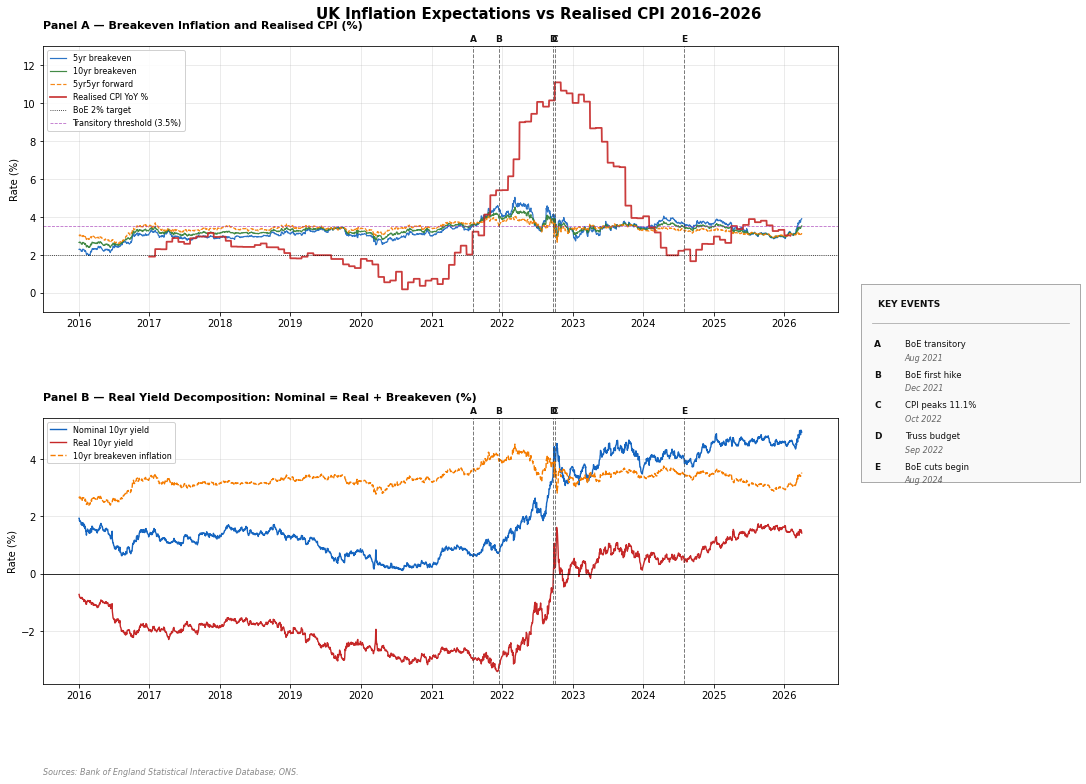

Chart saved.


In [10]:
# ============================================================
# CHART — BREAKEVEN INFLATION vs REALISED CPI
# ============================================================

# Align CPI to daily frequency for plotting alongside breakevens
# Forward fill monthly CPI to daily — standard approach for mixed frequency data
cpi_daily = cpi['cpi_yoy'].resample('D').ffill()
cpi_daily = cpi_daily[cpi_daily.index >= '2016-01-01']

fig, axes = plt.subplots(2, 1, figsize=(16, 11), facecolor='white')
fig.subplots_adjust(top=0.93, hspace=0.40, right=0.76, left=0.07)
fig.suptitle('UK Inflation Expectations vs Realised CPI 2016–2026',
             fontsize=15, fontweight='bold', y=0.98)

event_dates = {
    'A': ('BoE "transitory" language',  '2021-08-05'),
    'B': ('BoE first hike',             '2021-12-16'),
    'C': ('CPI peaks at 11.1%',         '2022-10-01'),
    'D': ('Truss budget',               '2022-09-23'),
    'E': ('BoE cuts begin',             '2024-08-01'),
}

# --- TOP PANEL: breakeven inflation at three tenors vs realised CPI ---
ax1 = axes[0]
ax1.set_facecolor('white')

# Breakeven series
ax1.plot(breakevens.index.to_pydatetime(), breakevens['be_5yr'].values,
         color='#1565C0', linewidth=1.2, label='5yr breakeven', alpha=0.9)
ax1.plot(breakevens.index.to_pydatetime(), breakevens['be_10yr'].values,
         color='#2E7D32', linewidth=1.2, label='10yr breakeven', alpha=0.9)
ax1.plot(breakevens.index.to_pydatetime(), breakevens['fwd_5y5y'].values,
         color='#F57C00', linewidth=1.2, label='5yr5yr forward', alpha=0.9,
         linestyle='--')

# Realised CPI
ax1.plot(cpi_daily.index.to_pydatetime(), cpi_daily.values,
         color='#C62828', linewidth=1.8, label='Realised CPI YoY %',
         linestyle='-', alpha=0.9)

# BoE 2% target line
ax1.axhline(y=2.0, color='black', linewidth=0.8, linestyle=':',
            label='BoE 2% target')

# Transitory narrative threshold
ax1.axhline(y=3.5, color='#9C27B0', linewidth=0.8, linestyle='--',
            label='Transitory threshold (3.5%)', alpha=0.7)

# Event lines
for letter, (label, date) in event_dates.items():
    idx = breakevens.index.get_indexer([pd.Timestamp(date)], method='nearest')[0]
    x = breakevens.index[idx].to_pydatetime()
    ax1.axvline(x=x, color='#444444', linestyle='--', linewidth=1.0, alpha=0.7)
    ax1.text(x, 1.01, letter, fontsize=9, ha='center', va='bottom',
             color='#111111', fontweight='bold',
             transform=ax1.get_xaxis_transform())

ax1.set_title('Panel A — Breakeven Inflation and Realised CPI (%)',
              fontsize=11, fontweight='bold', loc='left', pad=18)
ax1.set_ylabel('Rate (%)', fontsize=10)
ax1.legend(loc='upper left', fontsize=8, framealpha=0.9)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.set_ylim(-1, 13)

# --- BOTTOM PANEL: real yield decomposition ---
ax2 = axes[1]
ax2.set_facecolor('white')

ax2.plot(breakevens.index.to_pydatetime(), breakevens['nom_10yr'].values,
         color='#1565C0', linewidth=1.4, label='Nominal 10yr yield')
ax2.plot(breakevens.index.to_pydatetime(), breakevens['real_10yr'].values,
         color='#C62828', linewidth=1.4, label='Real 10yr yield')
ax2.plot(breakevens.index.to_pydatetime(), breakevens['be_10yr'].values,
         color='#F57C00', linewidth=1.4, label='10yr breakeven inflation',
         linestyle='--')

ax2.axhline(y=0, color='black', linewidth=0.8)

# Event lines
for letter, (label, date) in event_dates.items():
    idx = breakevens.index.get_indexer([pd.Timestamp(date)], method='nearest')[0]
    x = breakevens.index[idx].to_pydatetime()
    ax2.axvline(x=x, color='#444444', linestyle='--', linewidth=1.0, alpha=0.7)
    ax2.text(x, 1.01, letter, fontsize=9, ha='center', va='bottom',
             color='#111111', fontweight='bold',
             transform=ax2.get_xaxis_transform())

ax2.set_title('Panel B — Real Yield Decomposition: Nominal = Real + Breakeven (%)',
              fontsize=11, fontweight='bold', loc='left', pad=18)
ax2.set_ylabel('Rate (%)', fontsize=10)
ax2.legend(loc='upper left', fontsize=8, framealpha=0.9)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())

# Key events legend box
ax_legend = fig.add_axes([0.78, 0.38, 0.19, 0.25], facecolor='#f9f9f9')
ax_legend.set_xticks([])
ax_legend.set_yticks([])
ax_legend.set_xlim(0, 1)
ax_legend.set_ylim(0, 1)
for spine in ax_legend.spines.values():
    spine.set_edgecolor('#aaaaaa')
    spine.set_linewidth(1.0)

ax_legend.text(0.08, 0.92, 'KEY EVENTS',
               transform=ax_legend.transAxes,
               fontsize=9, fontweight='bold', va='top', color='#111111')
ax_legend.plot([0.05, 0.95], [0.80, 0.80], color='#aaaaaa',
               linewidth=0.8, transform=ax_legend.transAxes)

entries = [
    ('A', 'BoE transitory',    'Aug 2021'),
    ('B', 'BoE first hike',    'Dec 2021'),
    ('C', 'CPI peaks 11.1%',   'Oct 2022'),
    ('D', 'Truss budget',      'Sep 2022'),
    ('E', 'BoE cuts begin',    'Aug 2024'),
]

for i, (letter, desc, date) in enumerate(entries):
    y = 0.72 - i * 0.155
    ax_legend.text(0.06, y, letter, transform=ax_legend.transAxes,
                   fontsize=9, fontweight='bold', va='top', color='#111111')
    ax_legend.text(0.20, y, desc, transform=ax_legend.transAxes,
                   fontsize=8.5, va='top', color='#111111')
    ax_legend.text(0.20, y - 0.07, date, transform=ax_legend.transAxes,
                   fontsize=8, va='top', color='#666666', style='italic')

fig.text(0.07, 0.01,
         'Sources: Bank of England Statistical Interactive Database; ONS.',
         fontsize=8, color='#888888', style='italic')

plt.savefig('outputs/charts/03_inflation_expectations.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Chart saved.")

## Findings So Far — Inflation Expectations and Real Yield Decomposition

**Systematic underpricing confirmed** — breakeven inflation peaked ~4.5% at 5yr tenor 
while realised CPI reached 11.1%. Markets never priced anything close to actual inflation.

**Two distinct phases of the gilt sell-off:**
- 2021: inflation expectations drove yields — real yields barely moved
- 2022: real yields surged 284bps as hiking cycle delivered genuine real tightening

**5yr5yr forward peaked January 2022 at 3.80%** — before the CPI peak. Long-run 
de-anchoring was at its worst before the hiking cycle began.

**Current:** 10yr breakeven 3.53%, 5yr5yr forward 3.15% — re-anchoring incomplete.

*Analysis continues below — transitory narrative threshold and investment signal.*

In [11]:
# ============================================================
# TRANSITORY NARRATIVE THRESHOLD ANALYSIS
# ============================================================

THRESHOLD = 3.5  # % — upper bound of anchored expectations
SUSTAINED_DAYS = 20  # business days above threshold to confirm breach

# Use 5yr breakeven as the primary series
be_5yr = breakevens['be_5yr'].copy()

# Identify days above threshold
above_threshold = be_5yr > THRESHOLD

# Find first sustained breach — 20 consecutive days above threshold
breach_date = None
consecutive = 0

for date, above in above_threshold.items():
    if above:
        consecutive += 1
        if consecutive >= SUSTAINED_DAYS and breach_date is None:
            # Find the start of this run
            breach_date = date - pd.offsets.BDay(SUSTAINED_DAYS - 1)
            breach_date = be_5yr.index[
                be_5yr.index.get_indexer([breach_date], method='nearest')[0]
            ]
    else:
        consecutive = 0

print(f"Transitory narrative threshold analysis:")
print(f"  Threshold:          {THRESHOLD}% (5yr breakeven)")
print(f"  Sustained period:   {SUSTAINED_DAYS} business days")
print(f"")
print(f"  First sustained breach: {breach_date.strftime('%B %Y')}")
print(f"  5yr breakeven on that date: "
      f"{be_5yr[breach_date]:.3f}%")
print(f"")

# Context — what else was happening at breach date
print(f"  Context at breach date:")
print(f"  BoE Bank Rate:     checking...")

# Find nearest BoE rate observation
boe = pd.read_csv('data/processed/boe_rate.csv', 
                   index_col=0, parse_dates=True)
boe_idx = boe.index.get_indexer([breach_date], method='nearest')[0]
print(f"  BoE proxy rate:    {boe.iloc[boe_idx].values[0]:.2f}%")

# CPI at breach date — nearest monthly observation  
cpi = pd.read_csv('data/processed/ons_cpi.csv',
                   index_col=0, parse_dates=True)
cpi_idx = cpi.index.get_indexer([breach_date], method='nearest')[0]
print(f"  Realised CPI YoY:  {cpi.iloc[cpi_idx]['cpi_yoy']:.2f}%")
print(f"  10yr nominal yield: "
      f"{breakevens.loc[breach_date, 'nom_10yr']:.3f}%")
print(f"  10yr real yield:    "
      f"{breakevens.loc[breach_date, 'real_10yr']:.3f}%")

Transitory narrative threshold analysis:
  Threshold:          3.5% (5yr breakeven)
  Sustained period:   20 business days

  First sustained breach: July 2021
  5yr breakeven on that date: 3.538%

  Context at breach date:
  BoE Bank Rate:     checking...
  BoE proxy rate:    0.05%
  Realised CPI YoY:  3.22%
  10yr nominal yield: 0.652%
  10yr real yield:    -2.952%


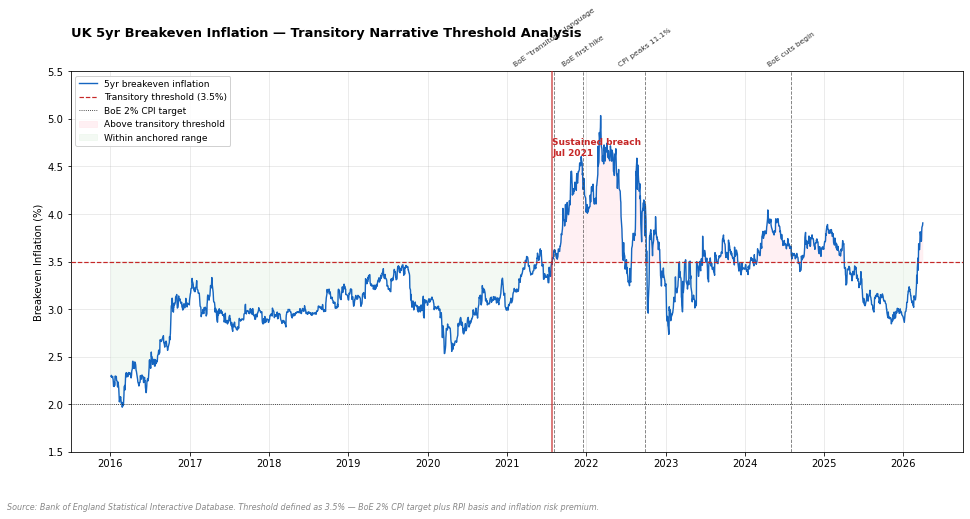

Chart saved.


In [12]:
# ============================================================
# CHART — TRANSITORY NARRATIVE THRESHOLD ANALYSIS
# ============================================================

fig, ax = plt.subplots(figsize=(16, 7), facecolor='white')
ax.set_facecolor('white')

# 5yr breakeven
ax.plot(breakevens.index.to_pydatetime(), breakevens['be_5yr'].values,
        color='#1565C0', linewidth=1.4, label='5yr breakeven inflation', zorder=3)

# Shade above threshold in red — period where narrative has broken
ax.fill_between(breakevens.index.to_pydatetime(),
                breakevens['be_5yr'].values, THRESHOLD,
                where=breakevens['be_5yr'].values > THRESHOLD,
                color='#FFEBEE', alpha=0.7, zorder=2,
                label='Above transitory threshold')

# Shade below threshold in green — period where narrative intact
ax.fill_between(breakevens.index.to_pydatetime(),
                breakevens['be_5yr'].values, THRESHOLD,
                where=breakevens['be_5yr'].values <= THRESHOLD,
                color='#E8F5E9', alpha=0.5, zorder=2,
                label='Within anchored range')

# Threshold line
ax.axhline(y=THRESHOLD, color='#C62828', linewidth=1.2,
           linestyle='--', label=f'Transitory threshold ({THRESHOLD}%)', zorder=4)

# BoE 2% target
ax.axhline(y=2.0, color='black', linewidth=0.8,
           linestyle=':', label='BoE 2% CPI target', zorder=4)

# Breach date vertical line
ax.axvline(x=breach_date.to_pydatetime(), color='#C62828',
           linewidth=1.5, linestyle='-', alpha=0.8, zorder=4)
ax.text(breach_date.to_pydatetime(), 4.8,
        f'Sustained breach\n{breach_date.strftime("%b %Y")}',
        fontsize=9, ha='left', va='top', color='#C62828',
        fontweight='bold')

# Key events
events = {
    'BoE "transitory"\nlanguage': '2021-08-05',
    'BoE first\nhike':            '2021-12-16',
    'CPI peaks\n11.1%':           '2022-10-01',
    'BoE cuts\nbegin':            '2024-08-01',
}

for label, date in events.items():
    idx = breakevens.index.get_indexer([pd.Timestamp(date)], method='nearest')[0]
    x = breakevens.index[idx].to_pydatetime()
    ax.axvline(x=x, color='#444444', linestyle='--',
               linewidth=0.9, alpha=0.7, zorder=3)
    ax.text(x, 1.01, label.replace('\n', ' '), fontsize=7.5,
            ha='center', va='bottom', color='#333333',
            transform=ax.get_xaxis_transform(), rotation=35)

ax.set_title('UK 5yr Breakeven Inflation — Transitory Narrative Threshold Analysis',
             fontsize=13, fontweight='bold', loc='left', pad=35)
ax.set_ylabel('Breakeven Inflation (%)', fontsize=10)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_ylim(1.5, 5.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())

fig.text(0.07, 0.01,
         'Source: Bank of England Statistical Interactive Database. '
         'Threshold defined as 3.5% — BoE 2% CPI target plus RPI basis and inflation risk premium.',
         fontsize=8, color='#888888', style='italic')

plt.savefig('outputs/charts/03b_transitory_threshold.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Chart saved.")

In [13]:
# ============================================================
# THRESHOLD SENSITIVITY ANALYSIS
# ============================================================

thresholds = [3.0, 3.25, 3.5, 3.75, 4.0]
SUSTAINED_DAYS = 20

print("Threshold sensitivity — breach date by threshold level:")
print("=" * 60)
print(f"{'Threshold':>10} {'Breach Date':>15} {'BE at breach':>14} {'Months before first hike'}")
print("-" * 60)

first_hike = pd.Timestamp('2021-12-16')

for threshold in thresholds:
    above = breakevens['be_5yr'] > threshold
    breach_date_t = None
    consecutive = 0
    
    for date, ab in above.items():
        if ab:
            consecutive += 1
            if consecutive >= SUSTAINED_DAYS and breach_date_t is None:
                breach_date_t = breakevens.index[
                    breakevens.index.get_indexer(
                        [date - pd.offsets.BDay(SUSTAINED_DAYS - 1)], 
                        method='nearest')[0]
                ]
        else:
            consecutive = 0
    
    if breach_date_t is not None:
        months_before = (first_hike - breach_date_t).days / 30.44
        be_at_breach = breakevens.loc[breach_date_t, 'be_5yr']
        print(f"{threshold:>9.2f}% {breach_date_t.strftime('%b %Y'):>15} "
              f"{be_at_breach:>13.3f}% {months_before:>15.1f} months")
    else:
        print(f"{threshold:>9.2f}% {'Never breached':>15}")

print("-" * 60)
print(f"\nBoE first hike: December 2021")
print(f"Finding robust if breach date consistently precedes first hike")
print(f"across all threshold levels.")

Threshold sensitivity — breach date by threshold level:
 Threshold     Breach Date   BE at breach Months before first hike
------------------------------------------------------------
     3.00%        Oct 2016         3.024%            61.9 months
     3.25%        May 2019         3.274%            31.1 months
     3.50%        Jul 2021         3.538%             4.6 months
     3.75%        Sep 2021         3.793%             3.3 months
     4.00%        Oct 2021         4.018%             2.1 months
------------------------------------------------------------

BoE first hike: December 2021
Finding robust if breach date consistently precedes first hike
across all threshold levels.


### Threshold Sensitivity — Key Observation

Thresholds below 3.5% (particularly 3.0% and 3.25%) produce breach dates 
that predate the inflation surge (2016 and 2019 respectively). This reflects 
the structural RPI premium embedded in UK breakeven inflation — index-linked 
gilts are RPI-linked, which structurally elevates breakevens by approximately 
100bps above CPI-equivalent expectations throughout the sample period.

At 3.5% and above, the threshold cleanly separates this structural premium 
from genuine de-anchoring. All thresholds from 3.5% to 4.0% identify a 
sustained breach in H2 2021 — consistently 2-5 months before the BoE's 
first rate hike in December 2021. The finding is therefore robust to 
threshold choice within the analytically meaningful range.

This confirms that gilt markets were pricing persistent above-target inflation 
before the BoE acted — the market led the central bank.

### Note — Forward-Looking Breakeven Validation

A formal forward-looking validation of breakeven inflation as a predictor of 
subsequent CPI was considered but not included. The available sample is unsuitable 
for this test for the following reason:

For start dates from late 2017 onwards, the 5yr forward window captures the 
2021-2023 inflation surge - an extreme, largely unpredictable event. This 
mechanically drives breakevens to appear as systematic underestimates regardless 
of their predictive quality. The result reflects the unpredictability of the 
inflation surge itself, not a finding about breakeven accuracy as a forecasting tool.

For start dates 2016 to mid-2017, breakevens marginally overestimated subsequent 
5yr CPI - consistent with the structural RPI premium (~100bps) embedded in 
UK index-linked gilt pricing.

A robust test of breakeven efficiency would require either a much longer historical 
dataset spanning multiple inflation cycles, or a formal econometric test of 
rational expectations - both beyond the scope of this project.

### Investment Signal — Nominal vs Index-Linked Gilts

The breakeven inflation rate provides a relative value signal for positioning 
between nominal and index-linked gilts. If an investor expects realised inflation 
to exceed the breakeven, index-linked gilts will outperform. If they expect 
inflation to undershoot the breakeven, nominals are preferred.

At key decision points in this cycle:

**January 2021** - the 10yr breakeven of 3.21% implied market expectations of 
approximately 2.1% CPI (adjusting for the ~100bps RPI basis). An investor who 
believed inflation would materially and persistently exceed this - as it did, 
reaching 11.1% by October 2022 - should have held index-linked gilts. The 
subsequent surge validated this positioning decisively.

**January 2022** - with the 10yr breakeven at 3.95% (implied CPI ~2.95%), 
nominals began to look more attractive for investors who believed the BoE would 
successfully bring inflation back toward target. As the hiking cycle progressed 
and breakevens fell from their peak, nominals outperformed from mid-2022 onwards 
as the real yield component drove both instruments lower but breakevens compressed.

**Current (March 2026)** - the 10yr breakeven at 3.53% (implied CPI ~2.53%) 
sits above the BoE's 2% target. For an investor who believes inflation will 
re-anchor fully to 2%, nominals offer better value. For an investor who believes 
inflation will remain structurally elevated above target, index-linked gilts 
remain attractive. The current breakeven level reflects genuine uncertainty 
about the inflation outlook rather than a clear directional signal.

*Note: A mechanical threshold-based signal was considered but rejected -
the UK RPI basis (~100bps) means breakevens are structurally elevated 
relative to CPI expectations throughout the sample, making simple threshold 
signals poorly calibrated. Positioning decisions require a forward inflation 
view, not just a breakeven observation.*